# 01 — Data Preparation

**Goal:** Load Banking77 from HuggingFace, audit data quality, carve fixed validation + dev splits from the train pool, and sample the stratified training subsets used by the fine-tune sweep in notebook 03.

## Sections

1. Load Banking77 via `datasets.load_dataset`
2. Schema audit + class-balance check
3. Query-length distribution (informs `max_length` for DistilBERT)
4. Confirm test holdout (Banking77 ships with an official test split — use it)
5. Carve fixed validation set (500 rows, stratified) from train pool
6. Carve dev slice (300 rows, stratified) from train pool — used for LLM prompt iteration in notebook 02
7. Sample stratified training subsets at n ∈ {50, 100, 250, 500, 1000, 2500, 5000} × 5 random seeds
8. Save processed splits to `data/processed/`

Why val + dev come from the train pool, not the test set: keeps the final test eval uncontaminated. The dev slice is used to iterate the LLM prompt; if it shared rows with test, the final test metrics would be optimistically biased.

## 1. Load Banking77

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
from huggingface_hub import hf_hub_download

PROCESSED_DIR = Path('../data/processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# PolyAI/banking77 ships an old script-based loader pointing at a dead GitHub URL.
# Bypass it by loading from HF Hub's auto-generated parquet revision instead.
REPO = 'PolyAI/banking77'
PARQUET_REV = 'refs/convert/parquet'
train_path = hf_hub_download(REPO, 'default/train/0000.parquet', revision=PARQUET_REV, repo_type='dataset')
test_path = hf_hub_download(REPO, 'default/test/0000.parquet', revision=PARQUET_REV, repo_type='dataset')

train_df = pd.read_parquet(train_path)
test_df = pd.read_parquet(test_path)

# Label names live in dataset_infos.json on the main branch
infos_path = hf_hub_download(REPO, 'dataset_infos.json', repo_type='dataset')
label_names = list(json.load(open(infos_path)).values())[0]['features']['label']['names']

print(f'Number of classes: {len(label_names)}')
print(f'Train size: {len(train_df):,}  ·  Test size: {len(test_df):,}')
print(f'\nFirst few rows of train:')
display(train_df.head())

Number of classes: 77
Train size: 10,003  ·  Test size: 3,080

First few rows of train:


,text,label
0,I am still waiting on my card?,11
1,What can I do if my card still hasn't arrived ...,11
2,I have been waiting over a week. Is the card s...,11
3,Can I track my card while it is in the process...,11
4,"How do I know if I will get my card, or if it ...",11


## 2. Schema audit + class-balance check

Sanity-check nulls + dtypes. Then look at examples-per-intent: any intent with fewer than 50 training examples will be at zero representation in the n=50 random-seed subsets, and may bite at larger n too. Visualise the distribution to see how rare the rare classes really are.

Nulls in train: {'text': 0, 'label': 0}
Nulls in test:  {'text': 0, 'label': 0}
Dtypes:         {'text': <StringDtype(na_value=nan)>, 'label': dtype('int64')}

Examples per intent (train):
  min:      35  (contactless_not_working)
  median:  127
  mean:    129.9
  max:     187  (card_payment_fee_charged)

Intents with <50 train examples: 2
label
contactless_not_working     35
virtual_card_not_working    41


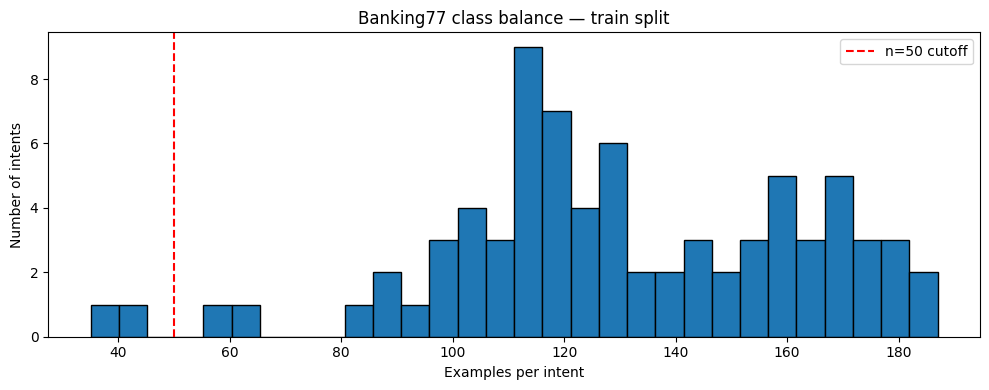

In [2]:
import matplotlib.pyplot as plt

print('Nulls in train:', train_df.isnull().sum().to_dict())
print('Nulls in test: ', test_df.isnull().sum().to_dict())
print('Dtypes:        ', train_df.dtypes.to_dict())

class_counts = train_df['label'].value_counts().sort_index()
class_counts_named = class_counts.copy()
class_counts_named.index = class_counts.index.map(lambda i: label_names[i])

print(f'\nExamples per intent (train):')
print(f'  min:    {class_counts.min():>4}  ({class_counts_named.idxmin()})')
print(f'  median: {int(class_counts.median()):>4}')
print(f'  mean:   {class_counts.mean():>6.1f}')
print(f'  max:    {class_counts.max():>4}  ({class_counts_named.idxmax()})')

low = class_counts_named[class_counts_named < 50]
print(f'\nIntents with <50 train examples: {len(low)}')
if len(low) > 0:
    print(low.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(class_counts.values, bins=30, edgecolor='black')
ax.axvline(50, color='red', linestyle='--', label='n=50 cutoff')
ax.set_xlabel('Examples per intent')
ax.set_ylabel('Number of intents')
ax.set_title('Banking77 class balance — train split')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Query-length distribution

Banking77 queries are typically short. Tokenise with the actual DistilBERT tokenizer (not whitespace count — that under-counts) and pick `MAX_LENGTH` to cover >99% of queries. Anything beyond MAX_LENGTH is truncated; we want truncation to be rare.

Train token-length stats (incl. [CLS] + [SEP]):
  min:        4
  median:    13
  max:       98
  95th p:    37
  99th p:    53


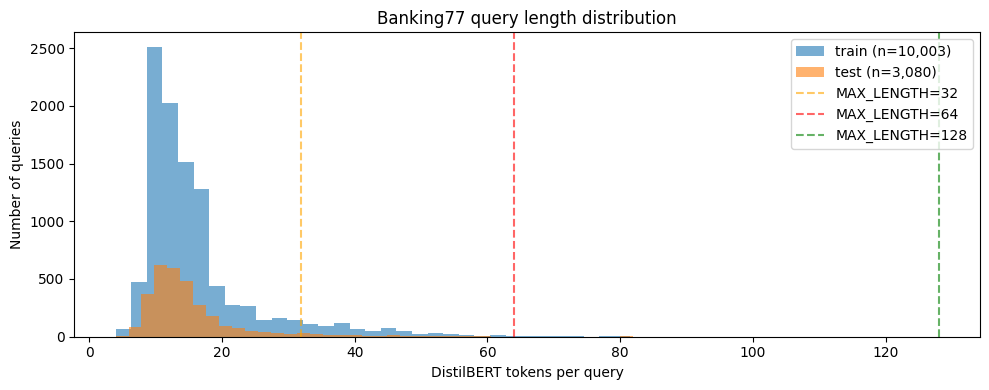

MAX_LENGTH=32: would truncate 7.01% of train queries
MAX_LENGTH=64: would truncate 0.30% of train queries
MAX_LENGTH=128: would truncate 0.00% of train queries


In [3]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

train_token_lens = np.array([len(tokenizer.encode(t, add_special_tokens=True)) for t in train_df['text']])
test_token_lens = np.array([len(tokenizer.encode(t, add_special_tokens=True)) for t in test_df['text']])

print('Train token-length stats (incl. [CLS] + [SEP]):')
print(f'  min:     {train_token_lens.min():>4}')
print(f'  median:  {int(np.median(train_token_lens)):>4}')
print(f'  max:     {train_token_lens.max():>4}')
print(f'  95th p:  {int(np.percentile(train_token_lens, 95)):>4}')
print(f'  99th p:  {int(np.percentile(train_token_lens, 99)):>4}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(train_token_lens, bins=40, alpha=0.6, label=f'train (n={len(train_token_lens):,})')
ax.hist(test_token_lens, bins=40, alpha=0.6, label=f'test (n={len(test_token_lens):,})')
for cutoff, colour in [(32, 'orange'), (64, 'red'), (128, 'green')]:
    ax.axvline(cutoff, color=colour, linestyle='--', alpha=0.6, label=f'MAX_LENGTH={cutoff}')
ax.set_xlabel('DistilBERT tokens per query')
ax.set_ylabel('Number of queries')
ax.set_title('Banking77 query length distribution')
ax.legend()
plt.tight_layout()
plt.show()

pct99 = int(np.percentile(train_token_lens, 99))
for cutoff in [32, 64, 128]:
    truncated_pct = 100 * (train_token_lens > cutoff).mean()
    print(f'MAX_LENGTH={cutoff}: would truncate {truncated_pct:.2f}% of train queries')

## 4. Test holdout

Banking77 has an official test split (3,080 rows). Use it — comparable to published baselines. This set is **only** touched by the final eval in notebook 02 and the DistilBERT evals in notebook 03. Never iterate on it.

Confirm the test class distribution roughly matches train, so the LLM baseline result generalises.

Classes present in train: 77 / 77
Classes present in test:  77 / 77

KL(test || train) = 0.0402  (close to 0 means distributions match)


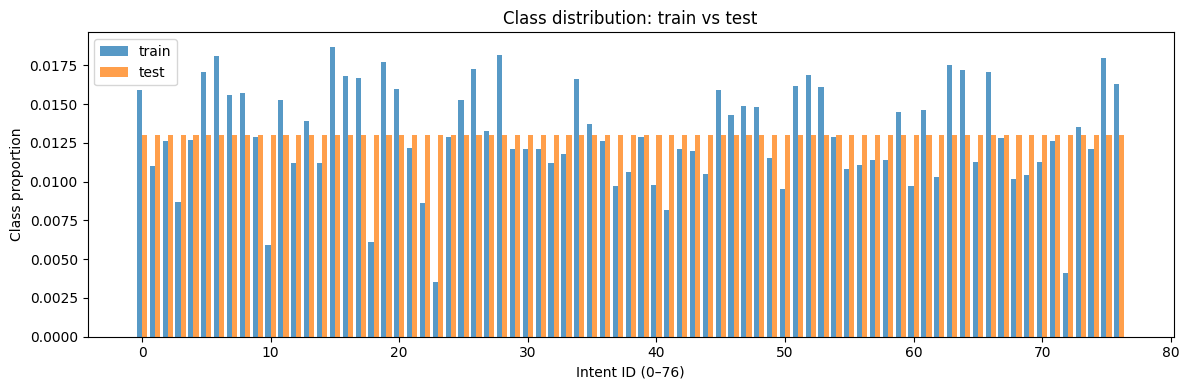

In [4]:
from scipy.stats import entropy

train_dist = train_df['label'].value_counts(normalize=True).sort_index()
test_dist = test_df['label'].value_counts(normalize=True).sort_index()

print(f'Classes present in train: {train_df["label"].nunique()} / 77')
print(f'Classes present in test:  {test_df["label"].nunique()} / 77')

kl_test_train = entropy(test_dist + 1e-12, train_dist + 1e-12)
print(f'\nKL(test || train) = {kl_test_train:.4f}  (close to 0 means distributions match)')

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(77)
ax.bar(x - 0.2, train_dist.reindex(range(77), fill_value=0).values, 0.4, label='train', alpha=0.75)
ax.bar(x + 0.2, test_dist.reindex(range(77), fill_value=0).values, 0.4, label='test', alpha=0.75)
ax.set_xlabel('Intent ID (0–76)')
ax.set_ylabel('Class proportion')
ax.set_title('Class distribution: train vs test')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Carve fixed validation set

Carve **500 stratified rows** from the 10,003-row train pool. Same 500 rows used as val for every n and every seed in notebook 03 — keeps early-stopping decisions comparable across the sweep.

In [5]:
from sklearn.model_selection import train_test_split

VAL_SET_SIZE = 500
RANDOM_SEED = 42

train_pool_after_val, val_df = train_test_split(
    train_df,
    test_size=VAL_SET_SIZE,
    stratify=train_df['label'],
    random_state=RANDOM_SEED,
)

val_df = val_df.reset_index(drop=True)
train_pool_after_val = train_pool_after_val.reset_index(drop=True)

print(f'Val set size:                {len(val_df):,}')
print(f'Train pool after val carve:  {len(train_pool_after_val):,}')
print(f'Classes present in val:      {val_df["label"].nunique()} / 77')

val_path = PROCESSED_DIR / 'val.parquet'
val_df.to_parquet(val_path)
print(f'\nSaved {val_path}')

Val set size:                500
Train pool after val carve:  9,503
Classes present in val:      77 / 77

Saved ../data/processed/val.parquet


## 6. Carve dev slice for LLM prompt iteration

Carve **300 stratified rows** from the remaining train pool as the dev slice. Used in notebook 02 for iterating the LLM prompt at low cost (~$1.50 per Sonnet 4.6 eval at this size, before prompt caching).

In [6]:
DEV_SLICE_SIZE = 300

train_pool, dev_df = train_test_split(
    train_pool_after_val,
    test_size=DEV_SLICE_SIZE,
    stratify=train_pool_after_val['label'],
    random_state=RANDOM_SEED,
)

dev_df = dev_df.reset_index(drop=True)
train_pool = train_pool.reset_index(drop=True)

print(f'Dev slice size:        {len(dev_df):,}')
print(f'Final train pool:      {len(train_pool):,}')
print(f'Classes in dev:        {dev_df["label"].nunique()} / 77')

dev_path = PROCESSED_DIR / 'dev_slice.parquet'
dev_df.to_parquet(dev_path)
print(f'\nSaved {dev_path}')

Dev slice size:        300
Final train pool:      9,203
Classes in dev:        77 / 77

Saved ../data/processed/dev_slice.parquet


## 7. Sample stratified training subsets across seeds

For each (n, seed) pair, draw an approximately-stratified subset of size n from the remaining train pool. **Subsets are nested within seed** — for seed=0, n=100 is a superset of n=50 etc. — so comparing across n at the same seed isolates the effect of adding more data, not the effect of different examples.

Implementation: for each seed, shuffle each label's examples with that seed, then interleave round-robin across labels. The resulting order is approximately balanced — taking the first n rows gives a near-stratified subset, and prefixes are nested by construction.

At n=50 with 77 classes, perfect stratification is impossible. Track and report which intents end up with zero training examples per (n, seed).

In [7]:
TRAINING_SIZES = [50, 100, 250, 500, 1000, 2500, 5000]
N_SEEDS = 5


def stratified_shuffle(df: pd.DataFrame, label_col: str, seed: int) -> np.ndarray:
    """Return df indices in round-robin-across-labels order.

    Within each label group, examples are shuffled with `seed`. Then groups
    are interleaved (cycling through label order, also shuffled with `seed`).
    Prefixes of the result are approximately stratified and nested.
    """
    rng = np.random.default_rng(seed)
    by_label: dict[int, np.ndarray] = {}
    for lbl in df[label_col].unique():
        idx = np.array(df.index[df[label_col] == lbl])  # writeable copy
        rng.shuffle(idx)
        by_label[int(lbl)] = idx

    label_order = sorted(by_label.keys())
    rng.shuffle(label_order)

    result: list[int] = []
    pointers = {lbl: 0 for lbl in by_label}
    while any(pointers[lbl] < len(by_label[lbl]) for lbl in label_order):
        for lbl in label_order:
            if pointers[lbl] < len(by_label[lbl]):
                result.append(int(by_label[lbl][pointers[lbl]]))
                pointers[lbl] += 1
    return np.array(result)


coverage_rows = []
for seed in range(N_SEEDS):
    shuffled_idx = stratified_shuffle(train_pool, 'label', seed)
    shuffled_pool = train_pool.loc[shuffled_idx].reset_index(drop=True)
    for n in TRAINING_SIZES:
        subset = shuffled_pool.iloc[:n].copy()
        classes_present = subset['label'].nunique()
        missing = 77 - classes_present
        path = PROCESSED_DIR / f'train_n{n}_seed{seed}.parquet'
        subset.reset_index(drop=True).to_parquet(path)
        coverage_rows.append({
            'seed': seed, 'n': n,
            'classes_present': classes_present,
            'classes_missing': missing,
        })

coverage = pd.DataFrame(coverage_rows)
print('Class coverage per (n, seed):')
print(coverage.pivot(index='n', columns='seed', values='classes_present').to_string())
print(f'\nSaved {N_SEEDS * len(TRAINING_SIZES)} training-subset parquets in {PROCESSED_DIR}/')

Class coverage per (n, seed):
seed   0   1   2   3   4
n                       
50    50  50  50  50  50
100   77  77  77  77  77
250   77  77  77  77  77
500   77  77  77  77  77
1000  77  77  77  77  77
2500  77  77  77  77  77
5000  77  77  77  77  77

Saved 35 training-subset parquets in ../data/processed/


## 8. Save processed splits

Test set + label names. Together with the val / dev / per-(n, seed) parquets above, this is everything notebooks 02–04 load via `src.data`.

In [8]:
test_path = PROCESSED_DIR / 'test.parquet'
test_df.reset_index(drop=True).to_parquet(test_path)
print(f'Saved {test_path} ({len(test_df):,} rows)')

labels_path = PROCESSED_DIR / 'label_names.txt'
labels_path.write_text('\n'.join(label_names))
print(f'Saved {labels_path} ({len(label_names)} labels)')

print('\n=== data/processed/ contents ===')
for p in sorted(PROCESSED_DIR.iterdir()):
    size_kb = p.stat().st_size / 1024
    print(f'  {p.name:<40} {size_kb:>10.1f} KB')

Saved ../data/processed/test.parquet (3,080 rows)
Saved ../data/processed/label_names.txt (77 labels)

=== data/processed/ contents ===
  dev_slice.parquet                              13.7 KB
  label_names.txt                                 1.6 KB
  test.parquet                                   86.1 KB
  train_n1000_seed0.parquet                      35.4 KB
  train_n1000_seed1.parquet                      35.4 KB
  train_n1000_seed2.parquet                      34.5 KB
  train_n1000_seed3.parquet                      35.6 KB
  train_n1000_seed4.parquet                      34.7 KB
  train_n100_seed0.parquet                        6.8 KB
  train_n100_seed1.parquet                        7.1 KB
  train_n100_seed2.parquet                        6.9 KB
  train_n100_seed3.parquet                        7.0 KB
  train_n100_seed4.parquet                        6.8 KB
  train_n2500_seed0.parquet                      85.1 KB
  train_n2500_seed1.parquet                      84.0 KB
  train_n

## Notes

- Train pool budget: 10,003 → minus 500 val → minus 300 dev → 9,203 available for n-subsets. n=5,000 still fits comfortably.
- Stratification at n=50 with 77 classes can't be perfect — see the coverage table in section 7. Report missing-class counts alongside per-(n, seed) macro-F1 in notebook 04 so readers can disentangle "model failed to learn the class" from "model never saw the class."
- `MAX_LENGTH` choice: section 3 plot will show that ~99% of queries fit in 32 tokens. Setting `MAX_LENGTH=64` in notebook 03 gives generous headroom with no meaningful cost — DistilBERT throughput is dominated by tokens-per-batch, and at 64 we're still well within T4 memory.